# Parsho RNA-scope tutorial

This notebook demonstrates a Parsho workflow for RNA-scope

In [39]:
# Necessary imports.
from pathlib import Path
import numpy as np
import pandas as pd
from cellpose import core, models
import cellpose.utils as utils_cell

from parsho.distribution import (
    compute_nucleus_centered_distribution,
    nucleus_centroids_by_cell,
)
from parsho.utils import (
    radial_distributions_to_records
)
from parsho.maskfilters import (
    build_overlay,
    compute_cell_metrics,
    filter_cells_by_overlap,
    mask_overlay_to_transfected,
    subtract_nuclear_from_aggregate,
)
from parsho.plotting import (
    plot_aggregate_channel,
    plot_aggregate_channel_color,
    plot_aggregate_channel_color_labelled,
    plot_nucleus_centered_distribution,
    plot_segmentation_result,
)
from parsho.segmentation import (
    extract_masks,
    find_optimal_threshold,
    re_threshold_masks,
)
from parsho.img_utils import (
    load_image
)


## Configuration

Parameters configuration for the run including control images and desired parameters for CellPose (Add guidelines)

In [40]:
# Folder path to results and data. Change this to your own path if you are running the tutorial outside of the parsho package.
DATA_DIR = Path("/media/ograciac/light-roast/ograciac/MorroCells/DatasetsParsho/RNA-scope")

# Parameters for the radial aggregate distribution analysis.
RADIAL_BINS = 10 # A value of 10 means that the radial distribution will be computed in 10 concentric rings around the nucleus.

# Common Cellpose parameters used for control images and the batch of images. For more information on these parameters, see the Cellpose documentation.
CELLPOSE_PARAMETERS = {
    "batch_size": 32,
    "diameter": None,  # Expected cell diameter in pixels.
    "flow_threshold": 0.4,
    "cellprob_threshold": -2.0,
    "min_size": 15, # Minimum expected size of cells in pixels. This is used to filter out small objects that are unlikely to be cells.
    "normalize": {"tile_norm_blocksize": 0},
}
GPU = core.use_gpu()

print(f"Using GPU: {GPU}")


Using GPU: True


In [41]:
# Load CellPoseSAM
model = models.CellposeModel(gpu=GPU)

## Image loading 

The aggregate channel is kept at its original intensity scale for quantitative measurements.

In [42]:
# Loading the data
example_name = "AVG_A1V1002.tif"

nuclei_channel = load_image(DATA_DIR / f"C1-{example_name}")
rna_trpv1_channel = load_image(DATA_DIR / f"C2-{example_name}")
rna_trpa1_channel = load_image(DATA_DIR / f"C3-{example_name}")
brightfield_channel = load_image(DATA_DIR / f"C4-{example_name}")

## Walk through one image set

Before running the batch, inspect one complete image set. The following cells displays the Cellpose segmentation, binary channel masks, categorical overlay, filtered labeled overlay, and nucleus-centered shape-adapted radial diagnostic using the plotting functions provided by Parsho.
This can be used to quickly spot artifacts or inadecuate parameters.

In this notebook all images follow the same naming convention with `C1-<name>` for nuclei, `C2-<name>` for aggregates, and `C3-<name>` for cells. 

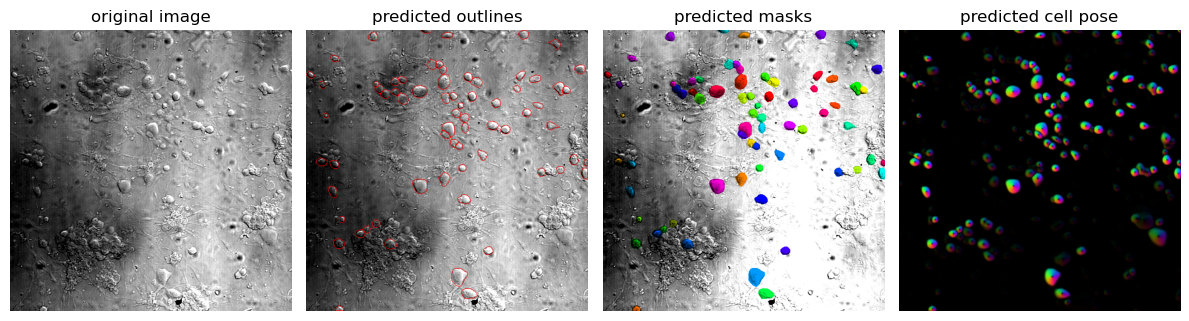

In [43]:
# Obtain cell masks for the example image set (using Cellpose)
cell_masks, cell_flows,  _ = model.eval(brightfield_channel, **CELLPOSE_PARAMETERS)
plot_segmentation_result(brightfield_channel, cell_masks, cell_flows)

TRPV1


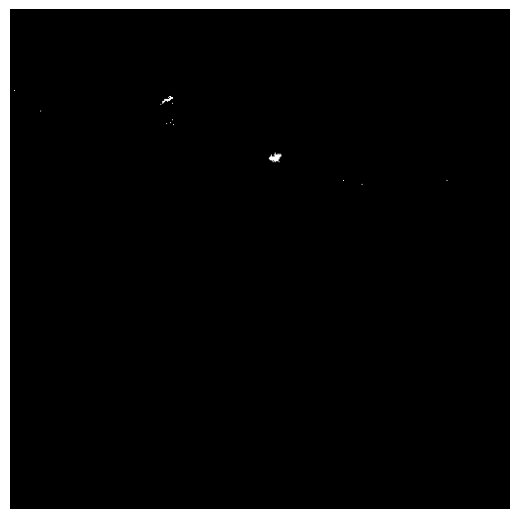

Nuclei


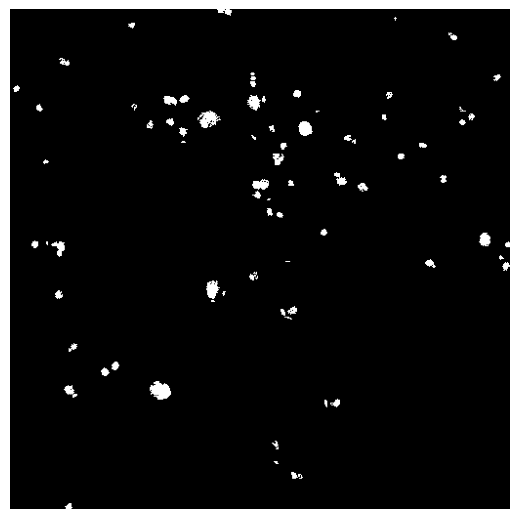

TRPA1


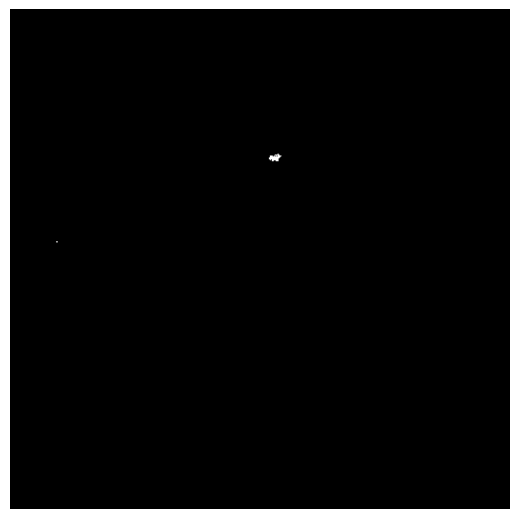

In [44]:
# Create masks for nuclear and RNA scope channels
trpv1_binary, trpv1_labels, _ = extract_masks(
    rna_trpv1_channel, cell_masks, method="otsu", min_size_px=1
)
nuc_binary, nuc_labels, _ = extract_masks(
    nuclei_channel, cell_masks, method="otsu", min_size_px=5
)
trpa1_binary, trpa1_labels, _ = extract_masks(
    rna_trpa1_channel, cell_masks, method="otsu", min_size_px=1
)

print("TRPV1")
plot_aggregate_channel(trpv1_binary)
print("Nuclei")
plot_aggregate_channel(nuc_binary)
print("TRPA1")
plot_aggregate_channel(trpa1_binary)

### Overlays

Plotting the overlays allows to visualize masks together. The parameters used in this notebook are quite permissive and some cell debris is mistakenly recognised as cells. The further filterings remove the small artifacts leaving only relevant transfected cells. 

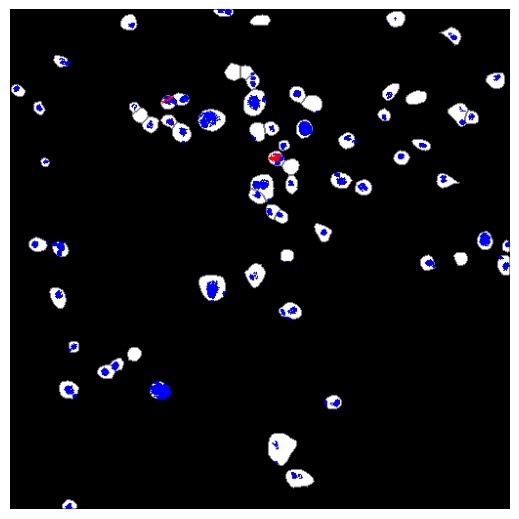

In [45]:
# Overlay the masks for TRPV1 and outlines on the original image for visualization
outlines = utils_cell.masks_to_outlines(cell_masks)
overlay = build_overlay(
    cell_masks, nuc_labels, trpv1_labels, outlines
)
plot_aggregate_channel_color(overlay)

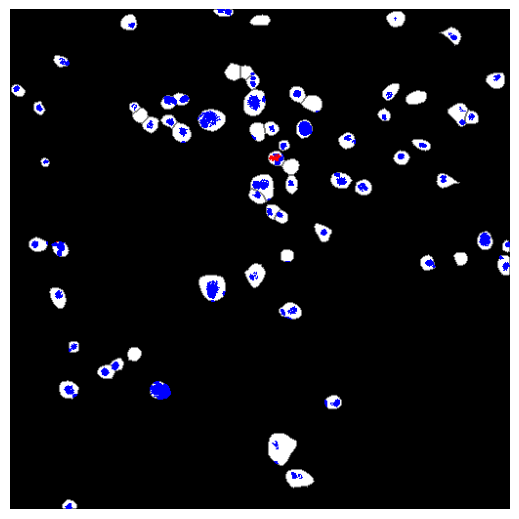

In [46]:
# Overlay the masks for TRPV1 and outlines on the original image for visualization
outlines = utils_cell.masks_to_outlines(cell_masks)
overlay = build_overlay(
    cell_masks, nuc_labels, trpa1_labels, outlines
)
plot_aggregate_channel_color(overlay)

### Cell labels

Each masked cell gets a unique label to allow matching the images to the extracted data. 

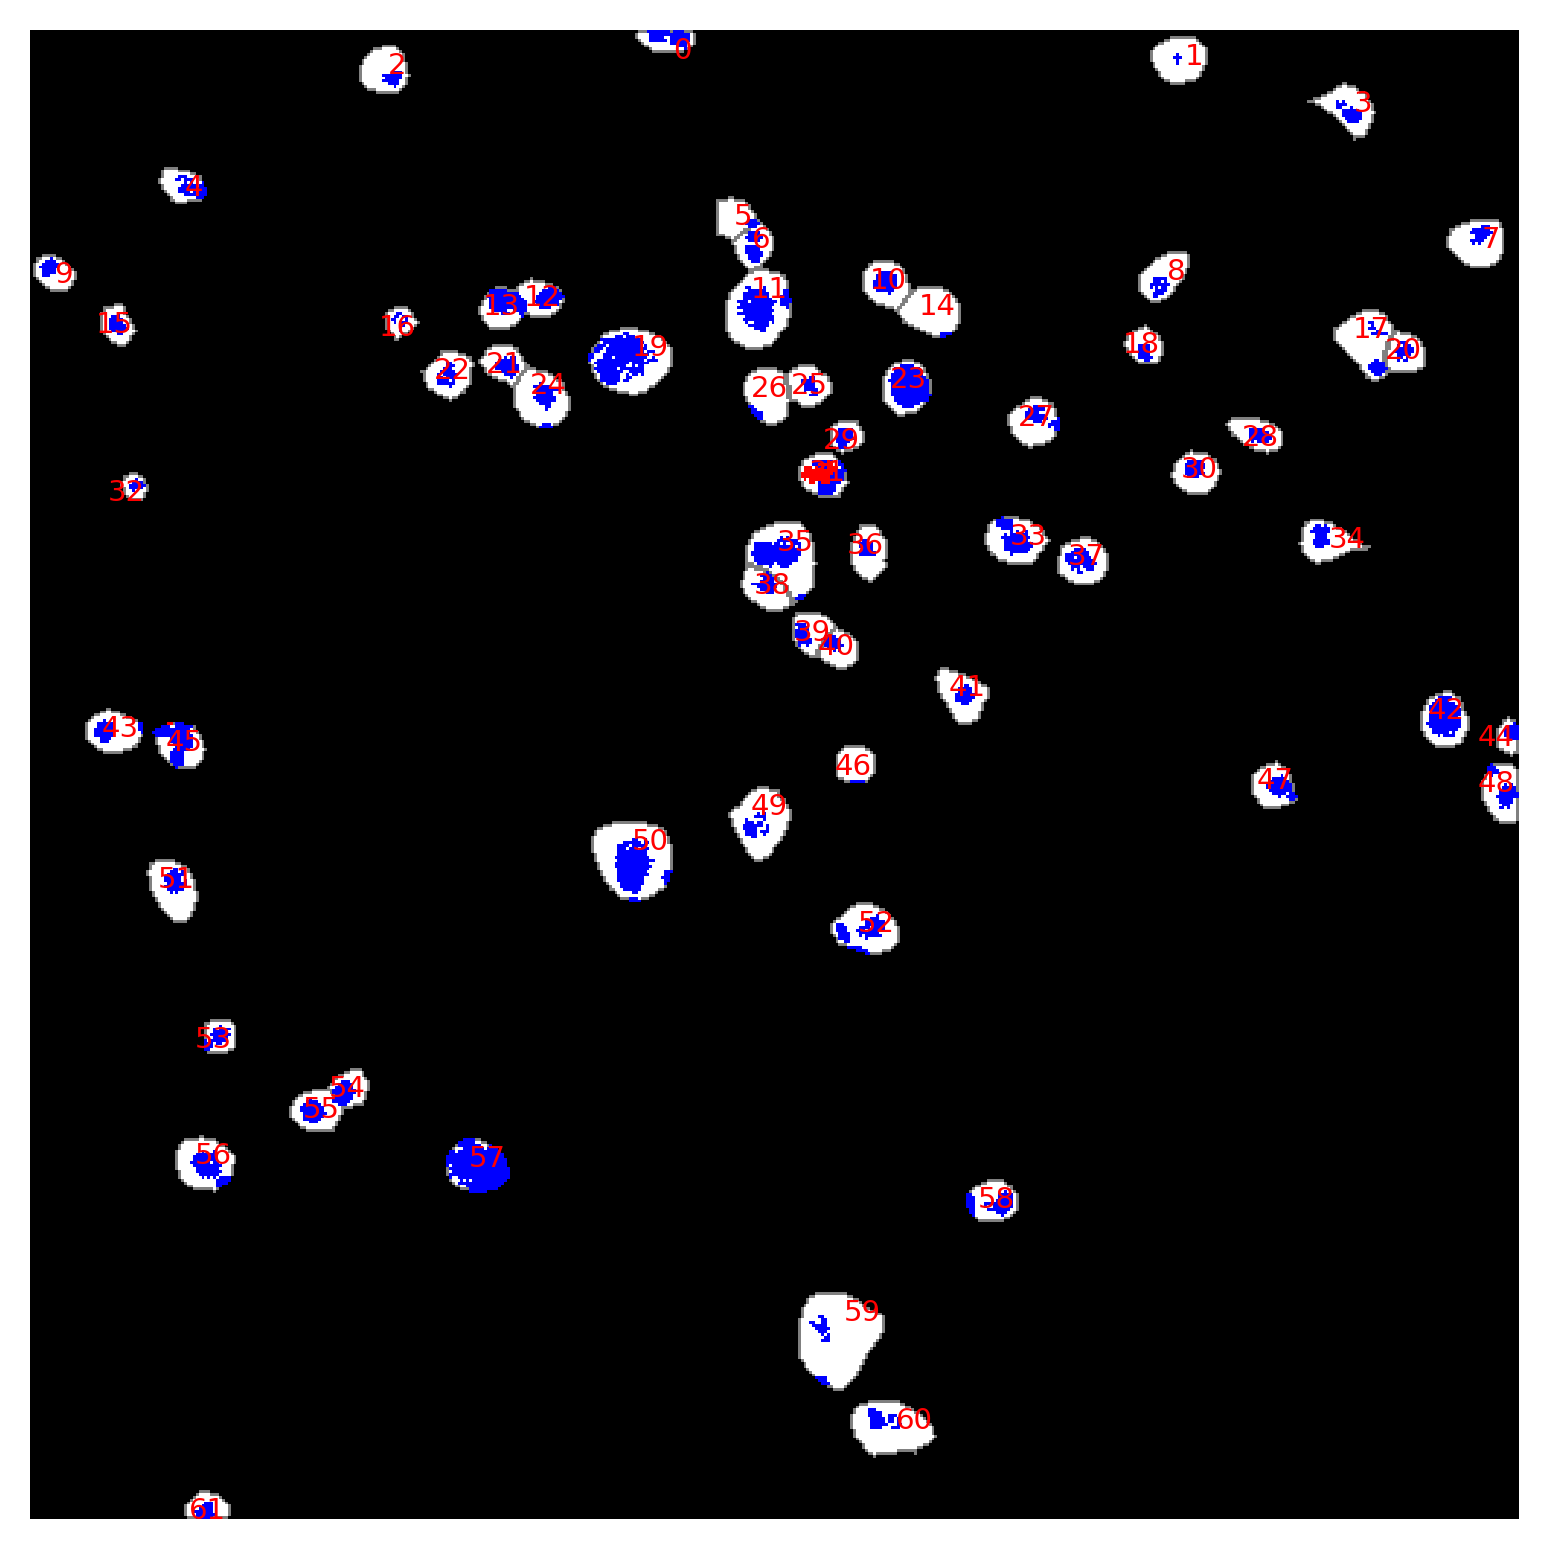

In [47]:
# Filter to keep only those with nucleous and label them
labels = filter_cells_by_overlap(
    cell_masks, nuc_labels
)
filtered_overlay = mask_overlay_to_transfected(
    overlay, cell_masks, labels
)

trpv1_records: list[dict]   = []
trpv1_text_mapping = {}
trpv1_reverse_text_mapping = {}
for jj, metrics in enumerate(compute_cell_metrics(cell_masks, nuc_labels, trpv1_labels, labels)):
    trpv1_records.append({
        "cell num":  jj,
        "cell area": metrics.cell_area,
        "agg area":  metrics.agg_area,
        "nuc area":  metrics.nuc_area,
        "jaccard":   metrics.jaccard,
        "cell aspect ratio": metrics.cell_aspect_ratio,
        "cell circularity": metrics.cell_circularity,
        "agg aspect ratio": metrics.agg_aspect_ratio,
        "agg circularity": metrics.agg_circularity
    })
    trpv1_text_mapping[metrics.label] = jj
    trpv1_reverse_text_mapping[jj] = metrics.label
    
plot_aggregate_channel_color_labelled(
    filtered_overlay, cell_masks, trpv1_text_mapping
)

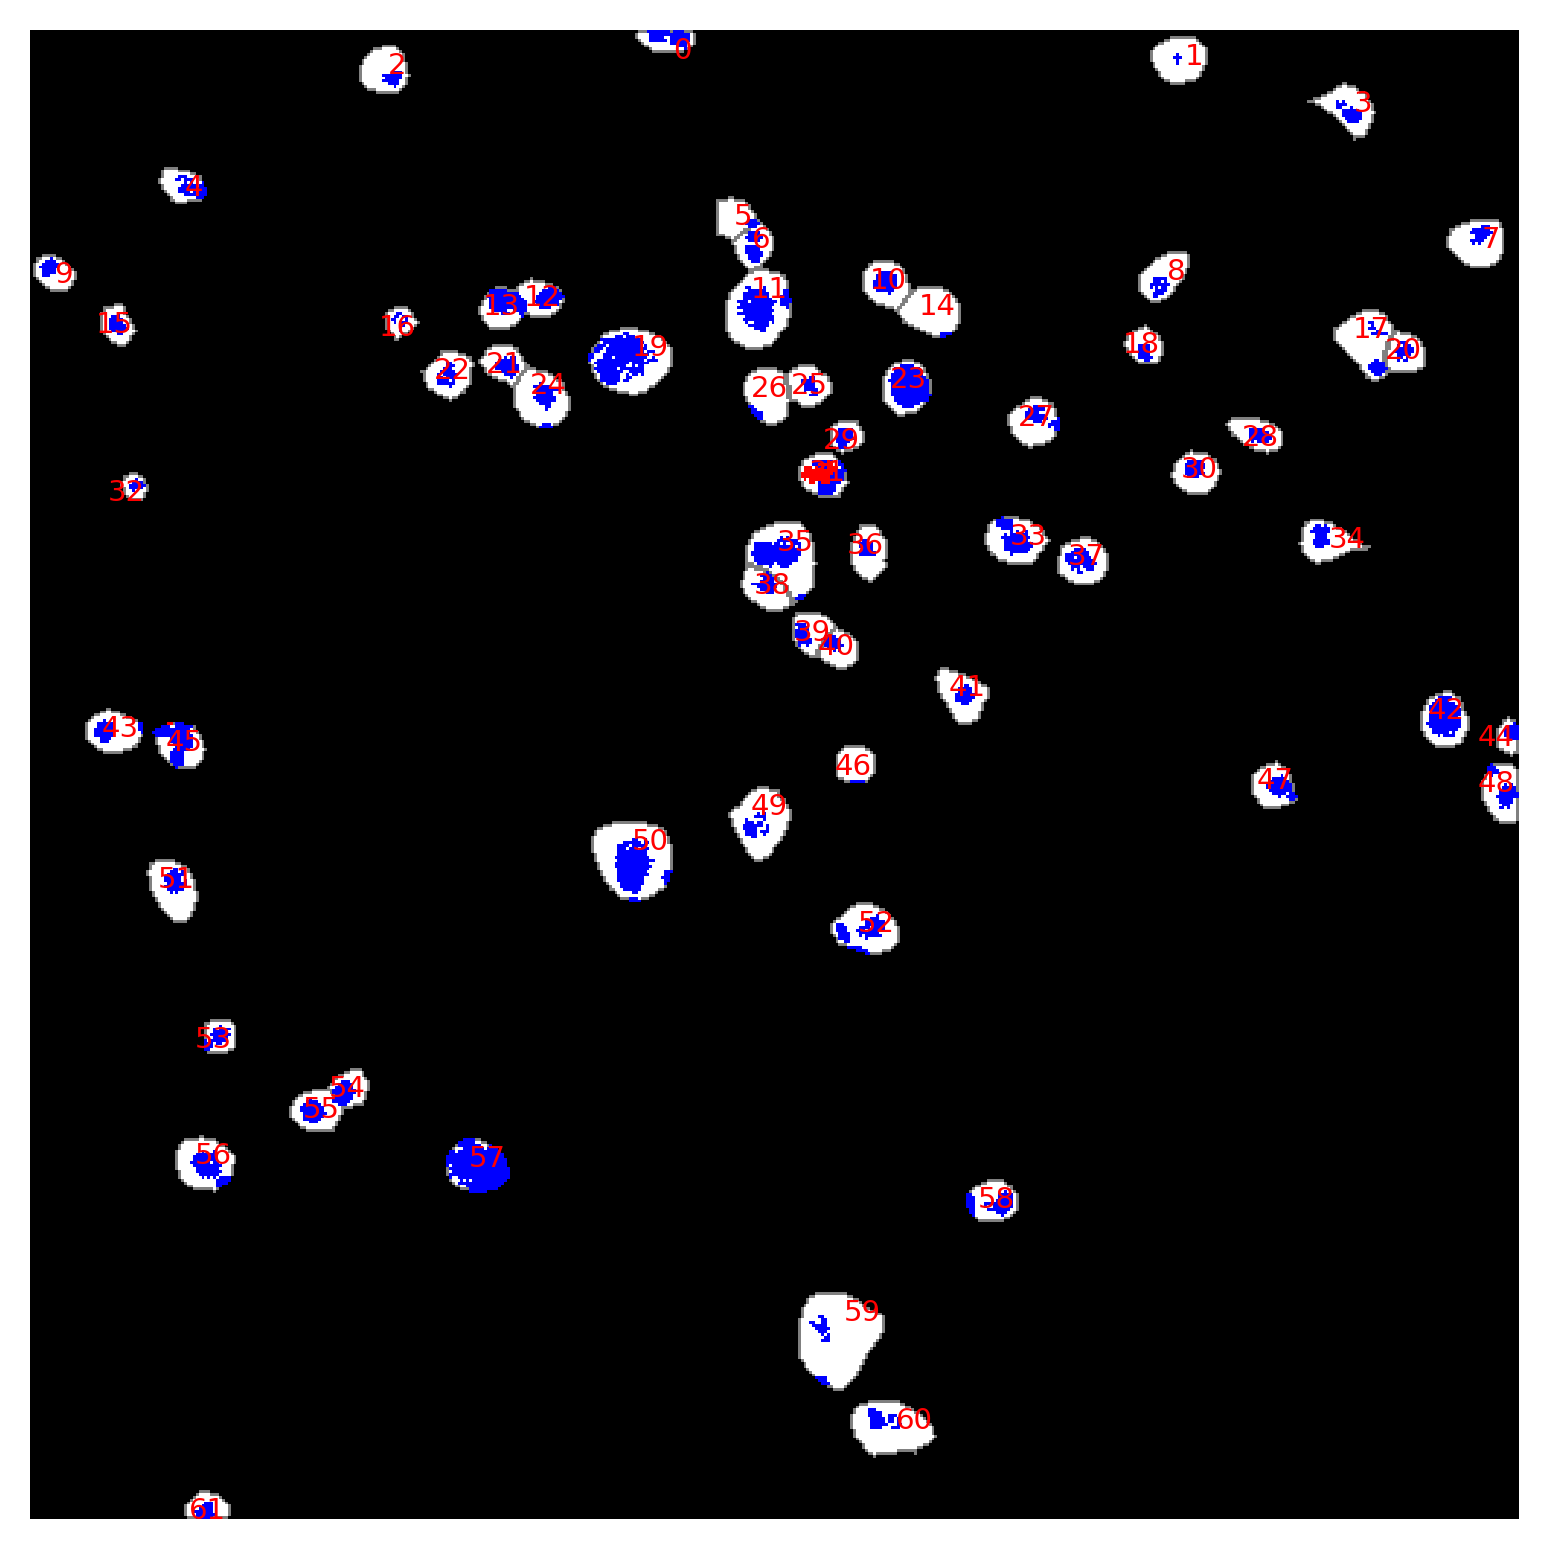

In [48]:
# Filter to keep only those with nucleous and label them
labels = filter_cells_by_overlap(
    cell_masks, nuc_labels
)
filtered_overlay = mask_overlay_to_transfected(
    overlay, cell_masks, labels
)

trpa1_records: list[dict]   = []
trpa1_text_mapping = {}
trpa1_reverse_text_mapping = {}
for jj, metrics in enumerate(compute_cell_metrics(cell_masks, nuc_labels, trpa1_labels, labels)):
    trpa1_records.append({
        "cell num":  jj,
        "cell area": metrics.cell_area,
        "agg area":  metrics.agg_area,
        "nuc area":  metrics.nuc_area,
        "jaccard":   metrics.jaccard,
        "cell aspect ratio": metrics.cell_aspect_ratio,
        "cell circularity": metrics.cell_circularity,
        "agg aspect ratio": metrics.agg_aspect_ratio,
        "agg circularity": metrics.agg_circularity
    })
    trpa1_text_mapping[metrics.label] = jj
    trpa1_reverse_text_mapping[jj] = metrics.label
    
plot_aggregate_channel_color_labelled(
    filtered_overlay, cell_masks, trpa1_text_mapping
)

## Radial distribution analysis TRPV1

The next section shows how to analyze the localization of the aggregates using the nucleus as cell center.
The module computes both pixels and cumulative intensity distributions. [ref1](https://link.springer.com/article/10.15252/embr.201541382) ,[ref2](https://www.nature.com/articles/s41467-024-44957-1)

In [49]:
# Radial distribution analysis for the transfected cells
trpv1_radial_intensity = rna_trpv1_channel.copy()
#trpv1_radial_intensity[nuc_binary != 0] = 0 Keep overlap with nucleous

nucleus_centroids = nucleus_centroids_by_cell(
    cell_masks, nuc_binary, cell_labels=labels
)
trpv1_radial_distributions = compute_nucleus_centered_distribution(
    cell_masks,
    nucleus_centroids,
    trpv1_binary,
    trpv1_radial_intensity,
    radial_bins=RADIAL_BINS,
    cell_labels=list(nucleus_centroids),
)


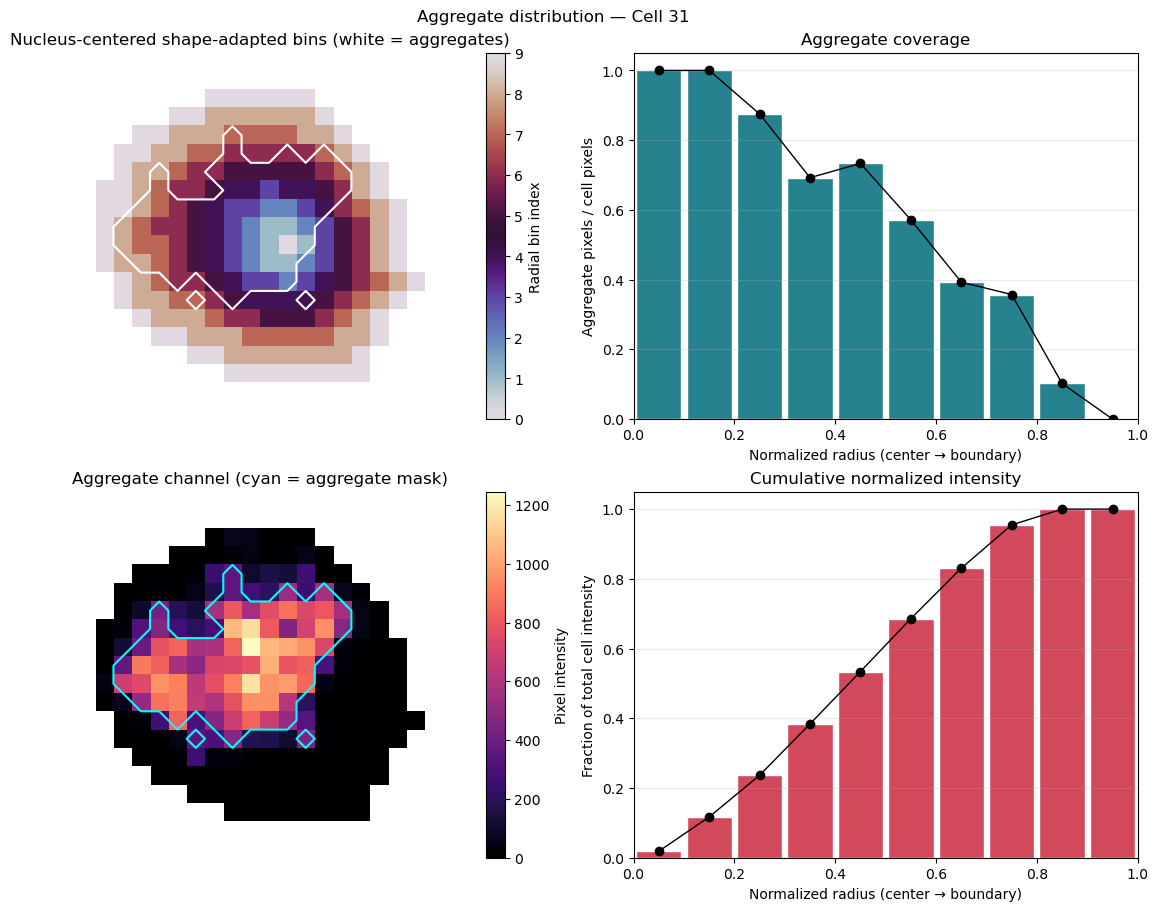

(<Figure size 1200x900 with 6 Axes>,
 {'sections': <Axes: title={'center': 'Nucleus-centered shape-adapted bins (white = aggregates)'}>,
  'channel': <Axes: title={'center': 'Aggregate channel (cyan = aggregate mask)'}>,
  'coverage': <Axes: title={'center': 'Aggregate coverage'}, xlabel='Normalized radius (center → boundary)', ylabel='Aggregate pixels / cell pixels'>,
  'intensity': <Axes: title={'center': 'Cumulative normalized intensity'}, xlabel='Normalized radius (center → boundary)', ylabel='Fraction of total cell intensity'>})

In [50]:
# Plotting of cells with their radial distributions. You can change the example_label to visualize different cells.
example_label = 31 # Change to any other cell label with aggregates to visualize its distribution
internal_label = trpv1_reverse_text_mapping[example_label]
plot_nucleus_centered_distribution(
    cell_masks,
    trpv1_binary,
    trpv1_radial_intensity,
    trpv1_radial_distributions[internal_label],
    cell_name=f"Cell {example_label}"
)

In [51]:
# Show results for all cells
pd.DataFrame(trpv1_records)

,cell num,cell area,agg area,nuc area,jaccard,cell aspect ratio,cell circularity,agg aspect ratio,agg circularity
0,0,142,0,62,0.0,2.511,0.770,0.0,0.0
1,1,265,0,6,0.0,1.156,0.980,0.0,0.0
2,2,236,0,28,0.0,1.032,0.985,0.0,0.0
3,3,236,0,39,0.0,1.489,0.738,0.0,0.0
4,4,159,0,48,0.0,1.475,0.896,0.0,0.0
...,...,...,...,...,...,...,...,...,...
57,57,325,0,287,0.0,1.203,0.963,0.0,0.0
58,58,216,0,67,0.0,1.199,1.002,0.0,0.0
59,59,742,0,38,0.0,1.155,0.891,0.0,0.0
60,60,436,0,47,0.0,1.535,0.843,0.0,0.0


In [52]:
# Show results for Radial distribution analysis for all cells
records_radial = radial_distributions_to_records(
    {example_name: trpv1_radial_distributions}
)
# Change the label to transfected cells
for record in records_radial:
    record["cell_label"] = trpv1_text_mapping[record["cell_label"]]

# Display results
radial_df = pd.DataFrame(records_radial)
display(radial_df)

,image_id,cell_label,centroid_row,centroid_column,radial_bin,radius_start,radius_end,section_size_pixels,aggregate_pixels,aggregate_present,aggregate_fraction,aggregate_share,intensity_sum,intensity_mean,intensity_share,cumulative_normalized_intensity
0,AVG_A1V1002.tif,0,2.048387,219.854839,0,0.0,0.1,1,0,False,0.0,0.0,0.0,0.0,0.0,0.0
1,AVG_A1V1002.tif,0,2.048387,219.854839,1,0.1,0.2,0,0,False,0.0,0.0,0.0,0.0,0.0,0.0
2,AVG_A1V1002.tif,0,2.048387,219.854839,2,0.2,0.3,3,0,False,0.0,0.0,0.0,0.0,0.0,0.0
3,AVG_A1V1002.tif,0,2.048387,219.854839,3,0.3,0.4,3,0,False,0.0,0.0,0.0,0.0,0.0,0.0
4,AVG_A1V1002.tif,0,2.048387,219.854839,4,0.4,0.5,7,0,False,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,AVG_A1V1002.tif,61,508.906250,59.843750,5,0.5,0.6,13,0,False,0.0,0.0,0.0,0.0,0.0,0.0
616,AVG_A1V1002.tif,61,508.906250,59.843750,6,0.6,0.7,14,0,False,0.0,0.0,0.0,0.0,0.0,0.0
617,AVG_A1V1002.tif,61,508.906250,59.843750,7,0.7,0.8,18,0,False,0.0,0.0,0.0,0.0,0.0,0.0
618,AVG_A1V1002.tif,61,508.906250,59.843750,8,0.8,0.9,27,0,False,0.0,0.0,0.0,0.0,0.0,0.0


## Radial distribution analysis TRPA1

The next section shows how to analyze the localization of the aggregates using the nucleus as cell center.

In [53]:
# Radial distribution analysis for the transfected cells
trpa1_radial_intensity = rna_trpa1_channel.copy()
#trpa1_radial_intensity[nuc_binary != 0] = 0 Keep overlap with nucleous

nucleus_centroids = nucleus_centroids_by_cell(
    cell_masks, nuc_binary, cell_labels=labels
)
trpa1_radial_distributions = compute_nucleus_centered_distribution(
    cell_masks,
    nucleus_centroids,
    trpa1_binary,
    trpa1_radial_intensity,
    radial_bins=RADIAL_BINS,
    cell_labels=list(nucleus_centroids),
)


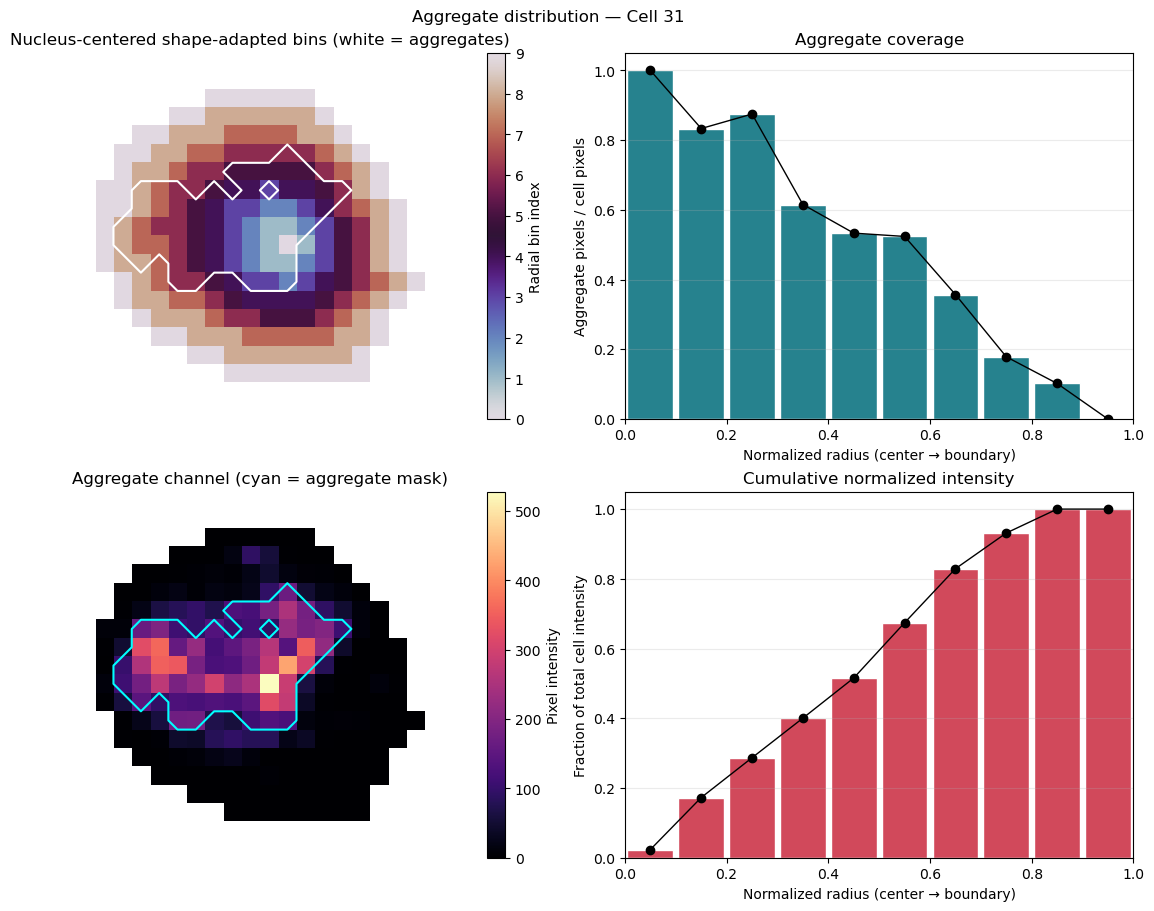

(<Figure size 1200x900 with 6 Axes>,
 {'sections': <Axes: title={'center': 'Nucleus-centered shape-adapted bins (white = aggregates)'}>,
  'channel': <Axes: title={'center': 'Aggregate channel (cyan = aggregate mask)'}>,
  'coverage': <Axes: title={'center': 'Aggregate coverage'}, xlabel='Normalized radius (center → boundary)', ylabel='Aggregate pixels / cell pixels'>,
  'intensity': <Axes: title={'center': 'Cumulative normalized intensity'}, xlabel='Normalized radius (center → boundary)', ylabel='Fraction of total cell intensity'>})

In [54]:
# Plotting of cells with their radial distributions. You can change the example_label to visualize different cells.
example_label = 31 # Change to any other cell label with aggregates to visualize its distribution
internal_label = trpa1_reverse_text_mapping[example_label]
plot_nucleus_centered_distribution(
    cell_masks,
    trpa1_binary,
    trpa1_radial_intensity,
    trpa1_radial_distributions[internal_label],
    cell_name=f"Cell {example_label}"
)

In [55]:
# Show results for all cells
pd.DataFrame(trpa1_records)


,cell num,cell area,agg area,nuc area,jaccard,cell aspect ratio,cell circularity,agg aspect ratio,agg circularity
0,0,142,0,62,0.0,2.511,0.770,0.0,0.0
1,1,265,0,6,0.0,1.156,0.980,0.0,0.0
2,2,236,0,28,0.0,1.032,0.985,0.0,0.0
3,3,236,0,39,0.0,1.489,0.738,0.0,0.0
4,4,159,0,48,0.0,1.475,0.896,0.0,0.0
...,...,...,...,...,...,...,...,...,...
57,57,325,0,287,0.0,1.203,0.963,0.0,0.0
58,58,216,0,67,0.0,1.199,1.002,0.0,0.0
59,59,742,0,38,0.0,1.155,0.891,0.0,0.0
60,60,436,0,47,0.0,1.535,0.843,0.0,0.0


In [56]:
# Show results for Radial distribution analysis for all cells
records_radial = radial_distributions_to_records(
    {example_name: trpa1_radial_distributions}
)
# Change the label to transfected cells
for record in records_radial:
    record["cell_label"] = trpa1_text_mapping[record["cell_label"]]

# Display results
radial_df = pd.DataFrame(records_radial)
display(radial_df)

,image_id,cell_label,centroid_row,centroid_column,radial_bin,radius_start,radius_end,section_size_pixels,aggregate_pixels,aggregate_present,aggregate_fraction,aggregate_share,intensity_sum,intensity_mean,intensity_share,cumulative_normalized_intensity
0,AVG_A1V1002.tif,0,2.048387,219.854839,0,0.0,0.1,1,0,False,0.0,0.0,0.0,0.0,0.0,0.0
1,AVG_A1V1002.tif,0,2.048387,219.854839,1,0.1,0.2,0,0,False,0.0,0.0,0.0,0.0,0.0,0.0
2,AVG_A1V1002.tif,0,2.048387,219.854839,2,0.2,0.3,3,0,False,0.0,0.0,0.0,0.0,0.0,0.0
3,AVG_A1V1002.tif,0,2.048387,219.854839,3,0.3,0.4,3,0,False,0.0,0.0,0.0,0.0,0.0,0.0
4,AVG_A1V1002.tif,0,2.048387,219.854839,4,0.4,0.5,7,0,False,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,AVG_A1V1002.tif,61,508.906250,59.843750,5,0.5,0.6,13,0,False,0.0,0.0,0.0,0.0,0.0,0.0
616,AVG_A1V1002.tif,61,508.906250,59.843750,6,0.6,0.7,14,0,False,0.0,0.0,0.0,0.0,0.0,0.0
617,AVG_A1V1002.tif,61,508.906250,59.843750,7,0.7,0.8,18,0,False,0.0,0.0,0.0,0.0,0.0,0.0
618,AVG_A1V1002.tif,61,508.906250,59.843750,8,0.8,0.9,27,0,False,0.0,0.0,0.0,0.0,0.0,0.0
